# Beta Pic Positive Control

**Objective**: Recover known asymmetric exocomet transits (dips) of $\beta$ Pictoris as a positive control test for the AstroHunter KZ pipeline.

*Note: This is a controlled statistical comparison and reproducible signal-detection pipeline test. It is not a claim of discovering exocomets.*

In [3]:
# 2. Imports and Paths
import sys
import warnings
from pathlib import Path
import pandas as pd

warnings.filterwarnings("ignore")

cwd = Path.cwd()

if cwd.name == "notebooks":
    project_root = cwd.parent
else:
    project_root = cwd

src_path = project_root / "src"

if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from astrohunter.lightcurves import download_and_stitch_lightcurves, lightcurve_to_dataframe
from astrohunter.asymmetry import detect_candidate_dips, add_asymmetry_scores
from astrohunter.plotting import plot_full_lightcurve, plot_event_window

results_dir = project_root / "results"
figures_dir = results_dir / "figures"
tables_dir = results_dir / "tables"

figures_dir.mkdir(parents=True, exist_ok=True)
tables_dir.mkdir(parents=True, exist_ok=True)


In [4]:
## 3. Download β Pic TESS Light Curves 

import lightkurve as lk

target_name = "TIC 270577175"

search = lk.search_lightcurve(target_name, mission="TESS")
print(search[:10])

lc_norm = search[0].download()
lc_norm = lc_norm.remove_nans()
lc_norm = lc_norm.remove_outliers(sigma=10)
lc_norm = lc_norm.normalize()

print("Downloaded one light curve successfully.")
print(lc_norm)

SearchResult containing 10 data products.

 #     mission     year author exptime target_name distance
                                  s                 arcsec 
--- -------------- ---- ------ ------- ----------- --------
  0 TESS Sector 04 2018   SPOC     120   270577175      0.0
  1 TESS Sector 05 2018   SPOC     120   270577175      0.0
  2 TESS Sector 06 2018   SPOC     120   270577175      0.0
  3 TESS Sector 07 2019   SPOC     120   270577175      0.0
  4 TESS Sector 32 2020   SPOC     120   270577175      0.0
  5 TESS Sector 33 2020   SPOC     120   270577175      0.0
  6 TESS Sector 34 2021   SPOC     120   270577175      0.0
  7 TESS Sector 87 2024   SPOC      20   270577175      0.0
  8 TESS Sector 87 2024   SPOC     120   270577175      0.0
  9 TESS Sector 95 2025   SPOC      20   270577175      0.0
Downloaded one light curve successfully.
       time             flux         flux_err    ...   pos_corr1      pos_corr2   
                                                 ... 

## 4. Convert to DataFrame

In [5]:
lc_df = lightcurve_to_dataframe(lc_norm)
print(f"Light curve contains {len(lc_df):,} points.")
display(lc_df.head())

Light curve contains 14,692 points.


,time_btjd,flux,flux_err
0,1410.903493,0.998968,0.000046
1,1410.904881,0.999570,0.000046
2,1410.906270,1.000035,0.000046
3,1410.907659,1.000589,0.000046
4,1410.909048,1.000944,0.000046


## 5. Plot Full Light Curve

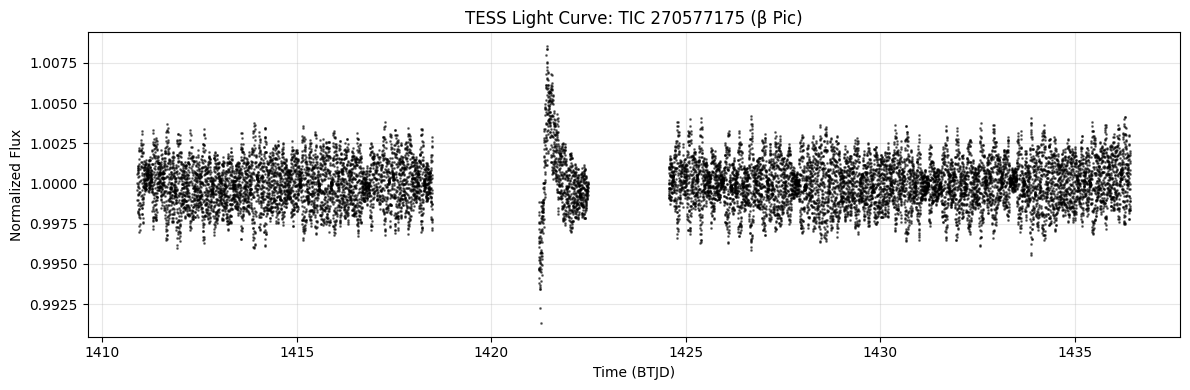

In [6]:
full_plot_path = figures_dir / "beta_pic_full_lightcurve.png"
plot_full_lightcurve(
    time=lc_df['time_btjd'].values,
    flux=lc_df['flux'].values,
    title=f"TESS Light Curve: {target_name} (β Pic)",
    output_path=full_plot_path
)

## 6. Run Simple Candidate Dip Detector

In [7]:
candidates_df = detect_candidate_dips(
    time=lc_df['time_btjd'].values,
    flux=lc_df['flux'].values,
    sigma_threshold=4.0,
    min_distance=5,
    window_days=0.5
)

print(f"Detected {len(candidates_df)} candidate dips passing threshold.")

Detected 5 candidate dips passing threshold.


## 7. Add Simple Asymmetry Scores

In [ ]:
candidates_scored = add_asymmetry_scores(
    events_df=candidates_df,
    time=lc_df['time_btjd'].values,
    flux=lc_df['flux'].values,
    window_days=0.5
)

# Sort by depth (deepest first)
candidates_scored = candidates_scored.sort_values('depth_ppm', ascending=False).reset_index(drop=True)
display(candidates_scored.head())

## 8. Save Candidate Table

In [ ]:
table_path = tables_dir / "beta_pic_candidate_dips.csv"
candidates_scored.to_csv(table_path, index=False)
print(f"Saved candidate dips to: {table_path}")

## 9. Plot Top 10 Candidate Event Windows

In [ ]:
top_10 = candidates_scored.head(10)

for i, row in top_10.iterrows():
    event_time = row['event_time_btjd']
    depth = row['depth_ppm']
    snr = row['snr_approx']
    asym = row['asymmetry_score']
    
    out_path = figures_dir / f"beta_pic_dip_{i+1:02d}_btjd_{event_time:.2f}.png"
    title = f"Dip #{i+1}: BTJD {event_time:.2f} | Depth: {depth:.0f} ppm | SNR: {snr:.1f} | Asym: {asym:.2f}"
    
    plot_event_window(
        time=lc_df['time_btjd'].values,
        flux=lc_df['flux'].values,
        event_time=event_time,
        window_days=0.5,
        title=title,
        output_path=out_path
    )

## 10. Summary

In [ ]:
print("="*50)
print(" BETA PIC POSITIVE CONTROL SUMMARY")
print("="*50)
print(f"Number of light curve points : {len(lc_df):,}")
print(f"Number of candidate dips     : {len(candidates_df)}")

if len(candidates_scored) > 0:
    deepest = candidates_scored.iloc[0]
    print(f"Deepest event depth          : {deepest['depth_ppm']:.0f} ppm (BTJD {deepest['event_time_btjd']:.2f})")
    
    print("\n--- Top 10 Events by Depth ---")
    summary_df = top_10[['event_time_btjd', 'depth_ppm', 'snr_approx', 'asymmetry_score']].copy()
    summary_df['depth_ppm'] = summary_df['depth_ppm'].round(0)
    summary_df['snr_approx'] = summary_df['snr_approx'].round(1)
    summary_df['asymmetry_score'] = summary_df['asymmetry_score'].round(2)
    display(summary_df)